# Using pretrained models to make predictions

In [12]:
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import dl4d as dds
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import models

In [13]:
model = '/home/gvaillant1/downscaling/pretrained-models/PSFC/PSFC-Other-Models/densenet_spc'

best_model = tf.keras.models.load_model(model)

In [14]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [15]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [16]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

In [17]:
#High resolution (uWRF) data
WS_hr_train = uwrf_train.WS
WS_hr_val = uwrf_val.WS
WS_hr_test = uwrf_test.WS

PSFC_hr_train = uwrf_train.PSFC
PSFC_hr_val = uwrf_val.PSFC
PSFC_hr_test = uwrf_test.PSFC

#--------------------------
#Low resolution (NAM) data
WS_lr_train = nam_train.WS
WS_lr_val = nam_val.WS
WS_lr_test = nam_test.WS

PSFC_lr_train = nam_train.PSFC
PSFC_lr_val = nam_val.PSFC
PSFC_lr_test = nam_test.PSFC

In [18]:
WS_scaler_train = dds.StandardScaler(axis=None)
WS_scaler_train.fit(WS_hr_train)  

PSFC_scaler_train = dds.StandardScaler(axis=None)
PSFC_scaler_train.fit(PSFC_hr_train)
#----------------------------------------------
#High resolution (uWRF):
y_z_train = WS_scaler_train.transform(WS_hr_train)
y_z_val = WS_scaler_train.transform(WS_hr_val)
y_z_test = WS_scaler_train.transform(WS_hr_test)


y_train = PSFC_scaler_train.transform(PSFC_hr_train)
y_val = PSFC_scaler_train.transform(PSFC_hr_val)
y_test = PSFC_scaler_train.transform(PSFC_hr_test)

#-------------------------------------------------
#Low resolution (NAM)

x_z_train = WS_scaler_train.transform(WS_lr_train)
x_z_val = WS_scaler_train.transform(WS_lr_val)
x_z_test = WS_scaler_train.transform(WS_lr_test)

x_train = PSFC_scaler_train.transform(PSFC_lr_train)
x_val = PSFC_scaler_train.transform(PSFC_lr_val)
x_test = PSFC_scaler_train.transform(PSFC_lr_test)

In [19]:
y_train = y_train.expand_dims(dim='channel', axis=-1)
y_val = y_val.expand_dims(dim='channel', axis=-1)
y_test = y_test.expand_dims(dim='channel', axis=-1)

y_z_train = y_z_train.expand_dims(dim ='channel', axis=-1)
y_z_val = y_z_val.expand_dims(dim ='channel', axis=-1)
y_z_test = y_z_test.expand_dims(dim ='channel', axis=-1)

#-----------------------------------------------------

x_train = x_train.expand_dims(dim='channel', axis=-1)
x_val = x_val.expand_dims(dim='channel', axis=-1)
x_test = x_test.expand_dims(dim='channel', axis=-1)

x_z_train = x_z_train.expand_dims(dim ='channel', axis=-1)
x_z_val = x_z_val.expand_dims(dim ='channel', axis=-1)
x_z_test = x_z_test.expand_dims(dim ='channel', axis=-1)

In [20]:
print("PSFC hr data shape:")
print(y_train.shape, y_val.shape, y_test.shape)
print("")
print("WS hr data shape:")
print(y_z_train.shape, y_z_val.shape, y_z_test.shape)
print("")
print("PSFC lr data shape:")
print(x_train.shape, x_val.shape, x_test.shape)
print("")
print("WS lr data shape:")
print(x_z_train.shape, x_z_val.shape, x_z_test.shape)

PSFC hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

WS hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PSFC lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

WS lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)


In [24]:
pred1 = dds.Predictor(
    best_model, 
    x_train, 
    scale=3, 
    array_in_hr=False,
    static_vars=None, 
    predictors=[x_z_train], 
    time_window=None,
    interpolation='inter_area', 
    batch_size=3,
    scaler=PSFC_scaler_train,
    save_path=None,
    save_fname=None,
    return_lr=True,
    device='CPU')

unscaled_x_pred, coarsened_array1 = pred1.run()

--------------------------------------------------------------------------------
Starting time: 2025-06-06 16:36:05
--------------------------------------------------------------------------------
899/899 [==============================] - 67s 74ms/step
--------------------------------------------------------------------------------
Final running time: 0:01:07.977852
--------------------------------------------------------------------------------


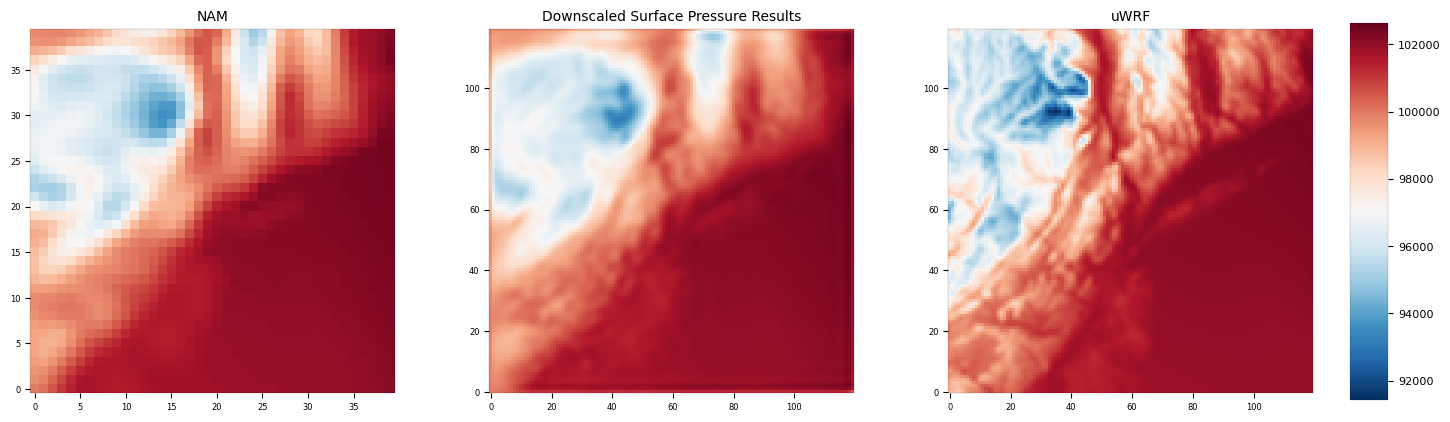

In [29]:
unscaled_x_train = PSFC_scaler_train.inverse_transform(x_train)
unscaled_y_train = PSFC_scaler_train.inverse_transform(y_train)

ecv.plot((unscaled_x_train[0].values, unscaled_x_pred[0], unscaled_y_train[0].values),
         share_colorbar=True, share_dynamic_range=True, subplot_titles=('NAM', 'Downscaled Surface Pressure Results', 'uWRF'))

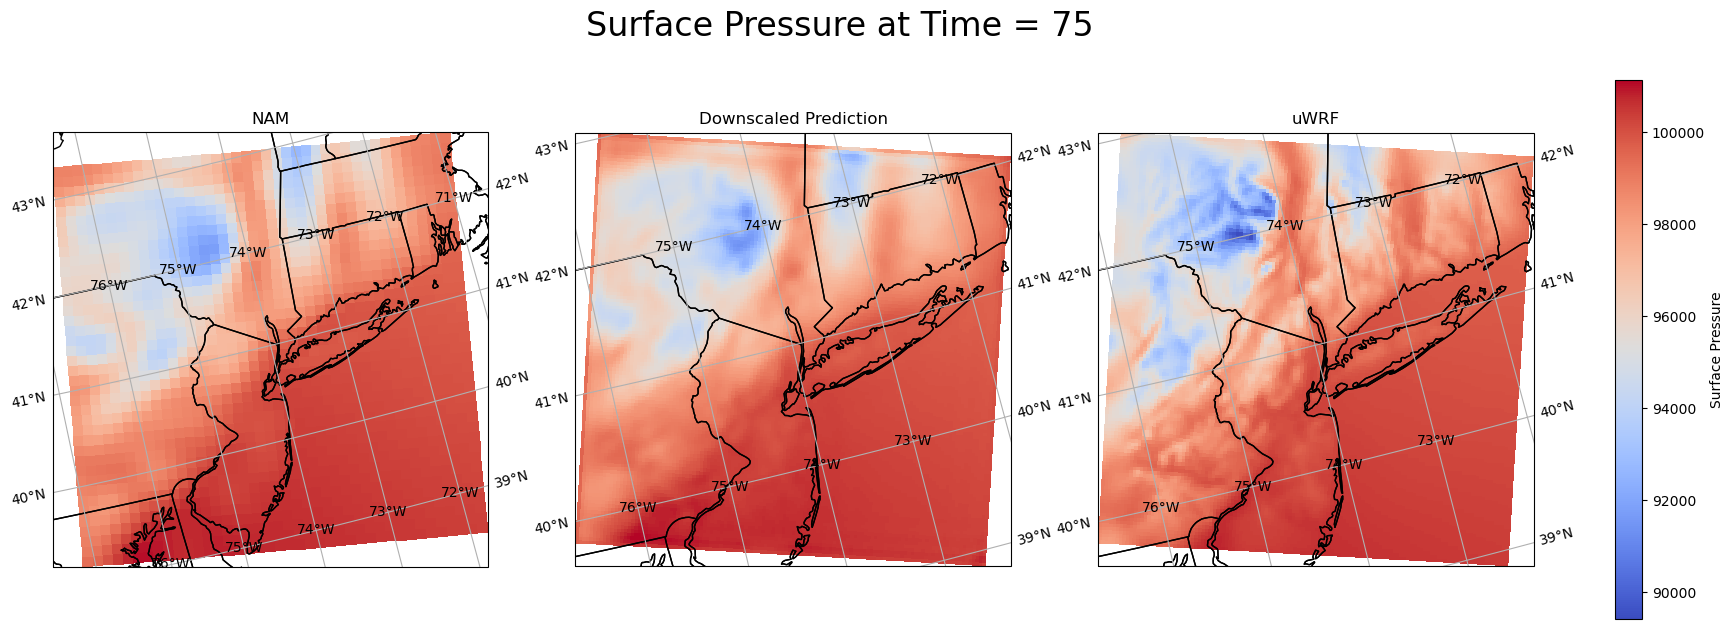

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature

# Extract data
nam = unscaled_x_train  # NAM
results = unscaled_x_pred  # Predicted output (numpy array)
uwrf = unscaled_y_train  # uWRF (truth)


# Select time index
time_idx = 75 # CHANGE

lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[time_idx,:,:].values

# Prediction values — want to be the same resolution as uWRF
t2_pred = results[time_idx, :, :]

# Determine common color limits
vmin = min(t2_nam.min(), t2_pred.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_pred.max(), t2_uwrf.max())


fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)

# Plot Prediction
im1 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'Downscaled Prediction')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[2].set_title(f'uWRF')
axes[2].coastlines()
axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Surface Pressure')

# Add main title
fig.suptitle(f'Surface Pressure at Time = {time_idx}', fontsize=24)


plt.show()